In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Chapter 9: Advanced Deep Learning for Computer Vision

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

We previously introduced you to the basic components of a convnet and how convolutional and maxpooling layers
work.  We looked at some simple deep learning models for computer vision, stacks of `Conv2D` and `MaxPooling2D` layers.

In this section we will look at other types of computer vision tasks than image classification.

## 9.3 Modern Convnet Architecture Patterns

### 9.3.1 Modularity, Hierarchy and Reuse

### 9.3.2 Residual Connections

Here is an example of a simple convnet structured into
a series of blocks, each made of two convolution layers and one optional
max pooling layer, with a residual connection around each block.

In [4]:
def residual_block(x, filters, pooling=False):
    """Example of a utility function and reuse in Keras function API.
    This creates a block that applies a convolution and sets up a
    residual connection around it, with an option to add
    a max pooling layer.

    Parameters
    ----------
    x : input
      The input coming into the block we want to add as residual after the block
    filters : int
      The size of the Conv2D filters to create in 2 convolution layers
    pooling : bool (default False)
      Option to also add a pooling layer downsample 2x and setup residual around it as well
    """
    residual = x
    # 2 consecutive convolution layers using filters specified added as block
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)

    # if asked to use pooling, add strided convolution to project the residual into
    # expected shape after downsampling
    if pooling:
        x = layers.MaxPooling2D(2, padding="same")(x)
        residual = layers.Conv2D(filters, 1, strides=2)(residual)
    # if we don't use max pooling, only need to project residual if number
    # of filter channels has changed
    elif filters != residual.shape[-1]:
        residual = layers.Conv2D(filters, 1)(residual)
    x = layers.add([x, residual])
    return x

In [5]:
# start of model Input, shape 32x32 with 3 channels
# and rescale to floats as usual expecting RGB int inputs
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(inputs)

# create first block with residual connection around it, has
# a max pooling layer that does 2x downsampling
x = residual_block(x, filters=32, pooling=True)

# create second block, note increasing filter count, again 2x downsampling using pooling
x = residual_block(x, filters=64, pooling=True)

# last block doesn't need a max pooling layer since we apply global average pooling right after it.
x = residual_block(x, filters=128, pooling=False)

# apply global average pooling after last block
x = layers.GlobalAveragePooling2D()(x)

# output layer for simple binary classification task
outputs = layers.Dense(1, activation="sigmoid")(x)

# create the model
model = keras.Model(inputs=inputs, outputs=outputs)

I0000 00:00:1749594209.419094   97727 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Lets look at the model summary, and also lets draw the model architecture graph.
Before you look at this, can you predict the layers and network graph with these
type of residual connections that were added?

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │        128 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     18,496 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │      2,112 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 8, 8, 64)  │          0 │ max_pooling2d_1[… │
│                     │                   │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │      8,320 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 8, 8, 128) │          0 │ conv2d_7[0][0],   │
│                     │                   │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 297,697 (1.14 MB)

 Trainable params: 297,697 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

The textual list of layers is a bit hard to visualize.  Residual connections effectively constitute nonsequential branches in the
network architecture.  So visualizing the network connection graph can be helpful here.  For example:

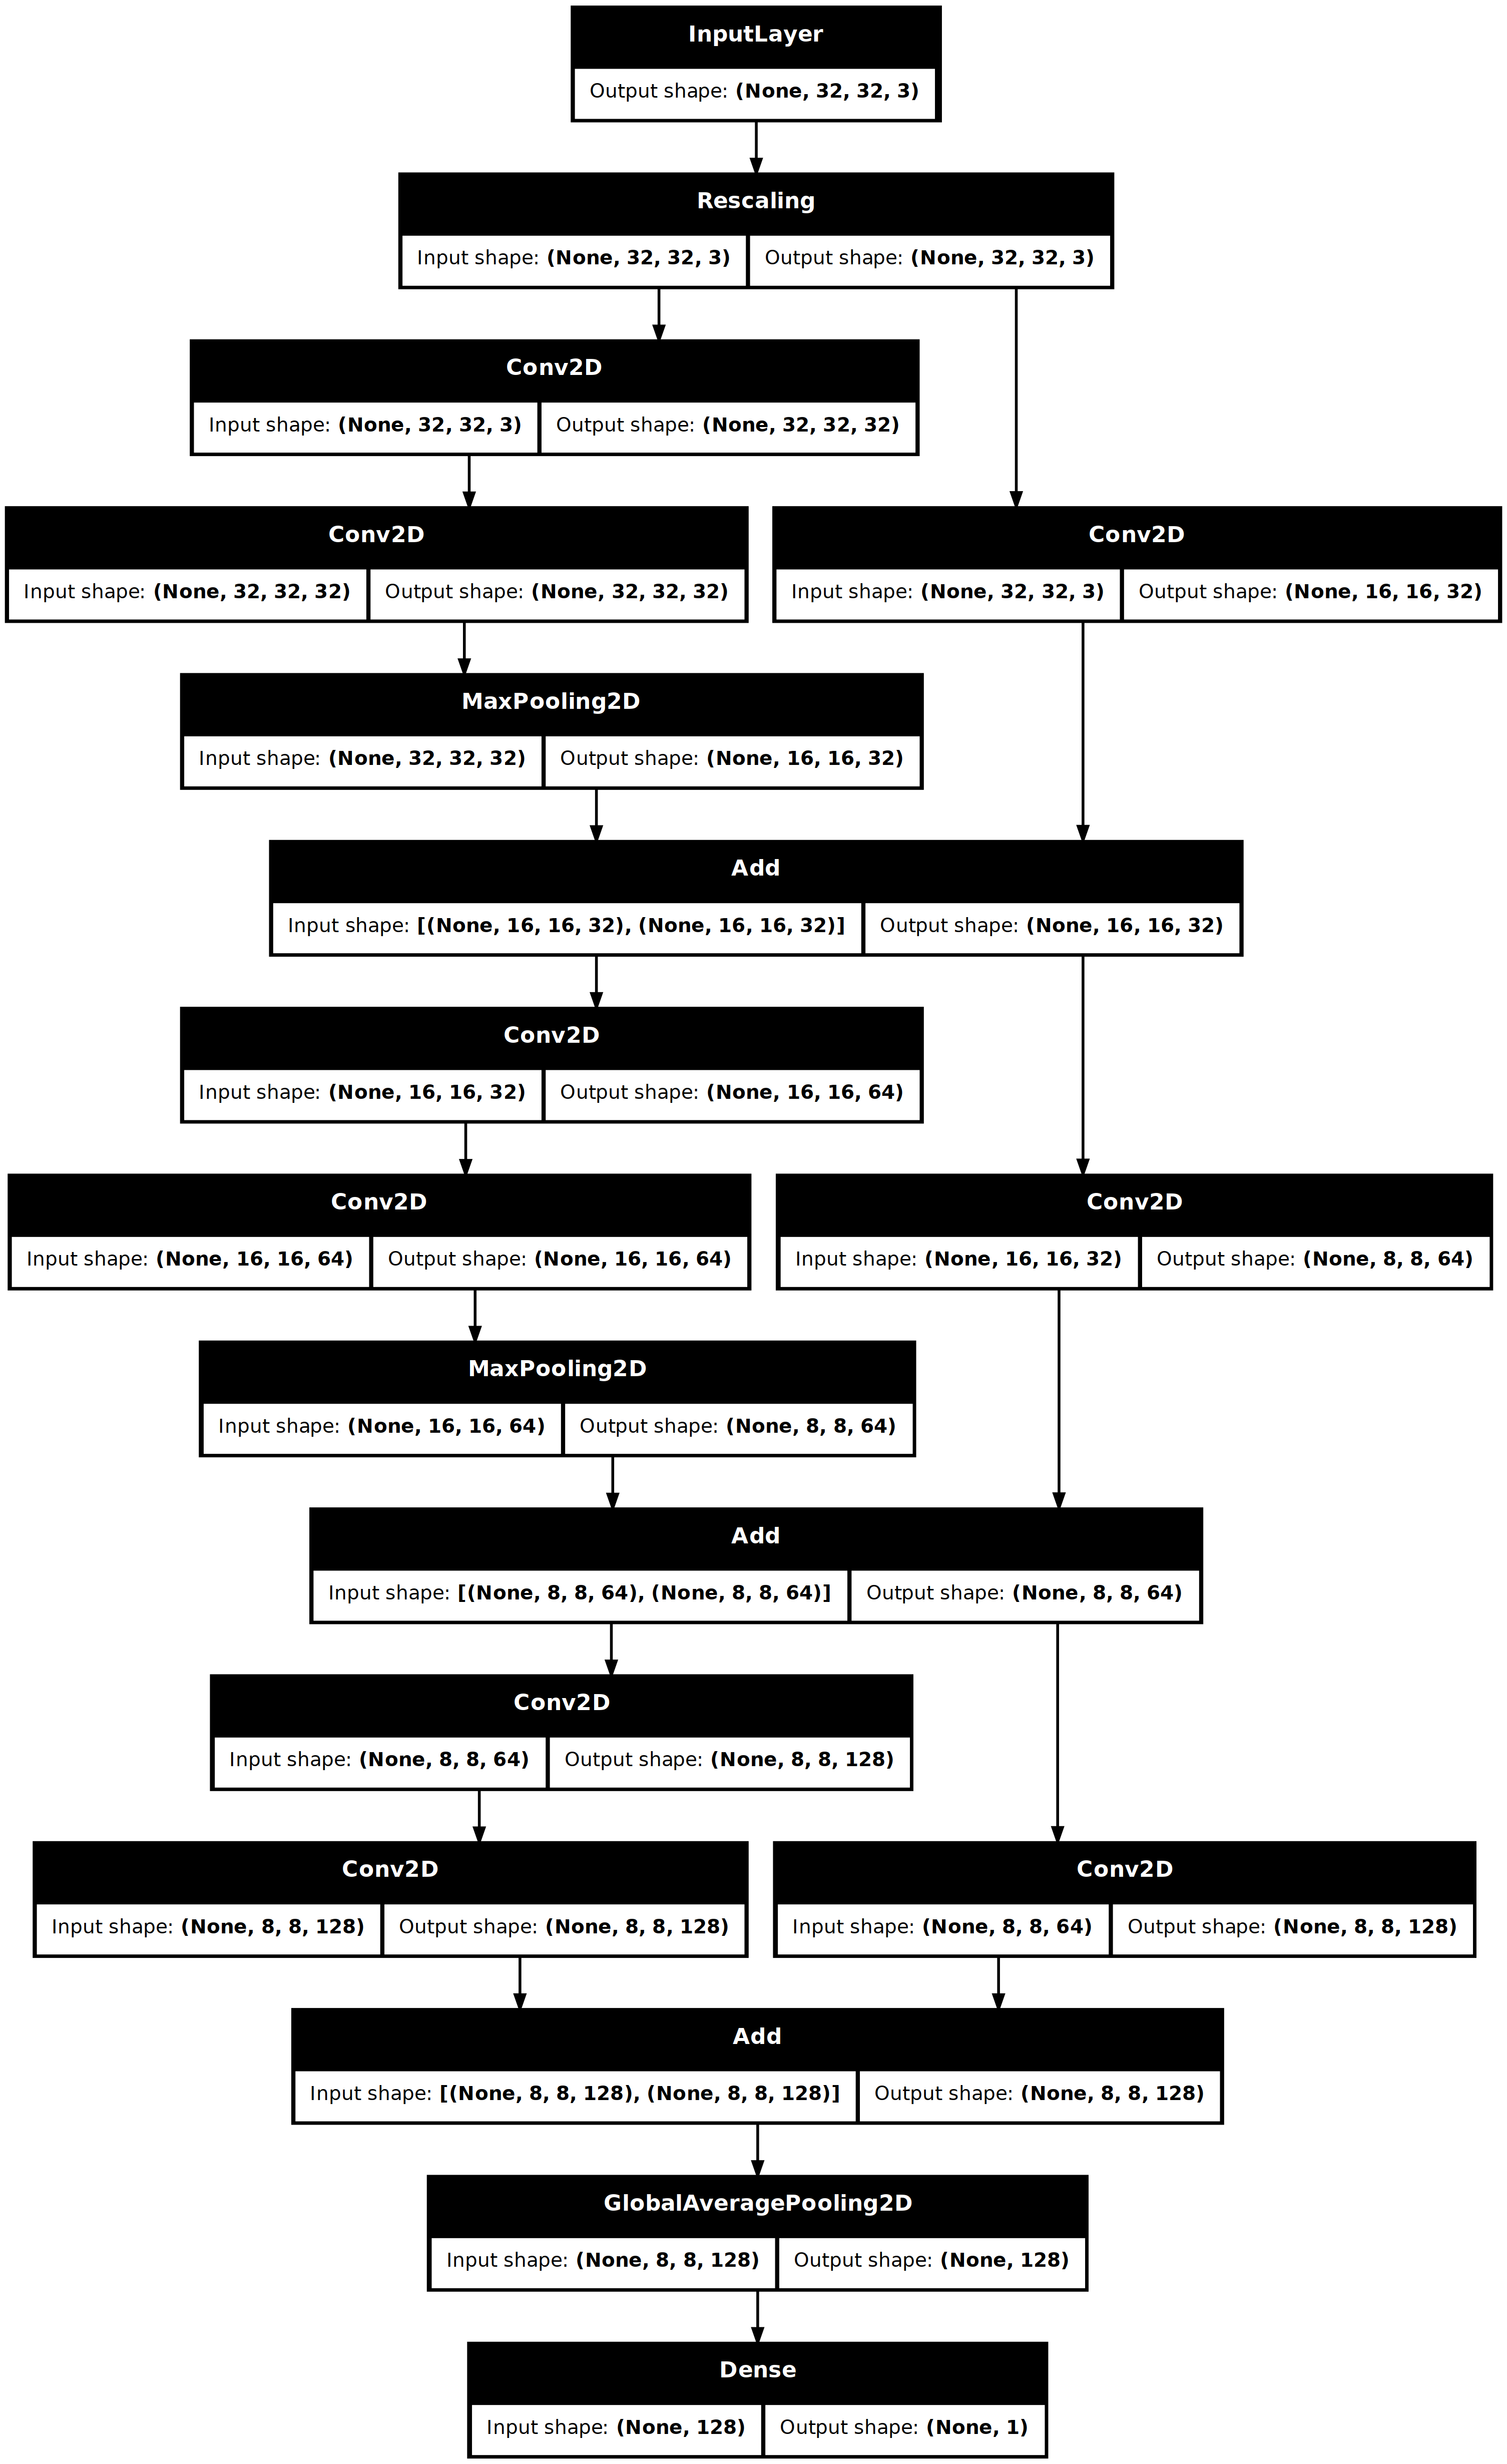

In [7]:
keras.utils.plot_model(model, "../figures/residual-connections-example-model.png", show_shapes=True)

### 9.3.3 Batch Normalization

### 9.3.4 Depthwise separable convolutions

### Summary of Convenet Best Practices: Residual Connections, Batch Normalization and Depthwise Separable Convolutions

Some of the important things to keep in mind about the Convnet Architecture design and the 3 specific convnet architecture elements we just discussed

<font color='blue'>

- Your model should be organized into repeated **blocks** of layers, usually made of multiple convolution layers
  and a max pooling layer.
- The number of filters in your layers should increse as the size of the spatial feature maps decreases.
- Deep and narrow is better than broad and shallow.
- Intoducing residual connections around blocks of layers helps you train deeper networks
  (avoids vanishing gradients)
- It can be beneficial to introduce batch normalization layers after your convolution layers
  (though reason why these work remain controversial, may also just be helping reduce vanishing gradients).
- It can be beneficial to replace `Conv2D` layers with `SeparableConv2D` layers, which are more
  parameter-efficient.


### 9.3.5 Putting it Together: A mini Xception-like model

The Xception model demonstrates many of the ideas and elements for convnet architecture best practices just
introduced.  

Just FYI the Xception model was, I believe, originally developed by our author Francois chollet in 2017.  The link
to the conference paper [Xception: Deep Learning with Depthwise Separable Convolutions, Conference on Computer Vision and Pattern Recognition 2017](https://arxiv.org/abs/1610.02357)

This example is a smaller version of that Xception, and we'll apply it to the dogs vs. cats task from the previous unit, so we are reusing
the setup from the first convnet example here.

In [8]:
# load dogs and cats data again to use in this example, creating
# tensorflow Dataset iterators for the training/testing
import os, shutil, pathlib
from tensorflow.keras.utils import image_dataset_from_directory

# top level director where we will store our smaller dataset 
new_base_dir = pathlib.Path("../data/cats_vs_dogs_small")

# notice the image_size and batch_size parameters here
train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)

validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)

test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


We'll replace the model from the brevious unit with an Xception like model.  Notice we
are building multiple "blocks" that have filters of sizes that progress: 32, 64, 128, 256, 512.

In each block a residual connection is made around the block to add unchanged inputs to next block

Also `Conv2D` layers have been replaced with the `SeparableConv2D` layers.

And `BatchNormalization` is done twice in each block, and as discussed biases are not used
and output `relu` activation is moved to after the batch normalization.

In [9]:
# we need to define the set of data augmentation layers to use before the main part of the model
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

In [10]:
inputs = keras.Input(shape=(180, 180, 3))

# we use the same data augmentation configuration as before
x = data_augmentation(inputs)

# don't forget input rescaling so RGB ints become floats in range 0-1
x = layers.Rescaling(1./255)(x)

# Note that the assumption that channels are largely independent does not
# hold at start for the initial RGB channels, which are actually highly
# correlated.  As such first layer is a regular Conv2D
x = layers.Conv2D(filters=32, kernel_size=5, use_bias=False)(x)


# we apply a series of convolutional blocks.  Each block consists of two
# batch-normalized depthwise separable convolution layers and a max pooling layer
# there is a residual connection around each of these blocks
for size in [32, 64, 128, 256, 512]:
    residual = x

    # first batch normalization and SeparableConv2D
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    # second batch normalization and Separable Conv2d
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(size, 3, padding="same", use_bias=False)(x)

    # downsample 2x using MaxPooling
    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # add in residual connections around above block
    residual = layers.Conv2D(size, 1, strides=2, padding="same", use_bias=False)(residual)
    x = layers.add([x, residual])

# in the original model, we use a Flatten layer before the Dense layer,
# here we go with a GlobalAveragePooling 2D layer
x = layers.GlobalAveragePooling2D()(x)

# like in original model, add in dropout layer for regularization
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

Lets look at the model summary, and especially the network graph of the resulting Xception like
model:

In [11]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 180, 180,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 180, 180,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 176, 176,  │      2,400 │ rescaling_1[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 176, 176,  │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 176, 176,  │      1,312 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 176, 176,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 176, 176,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 176, 176,  │      1,312 │ activation_1[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 88, 88,    │          0 │ separable_conv2d… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 88, 88,    │      1,024 │ conv2d_9[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 88, 88,    │          0 │ max_pooling2d_2[… │
│                     │ 32)               │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        128 │ add_3[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 88, 88,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 88, 88,    │      2,336 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 88, 88,    │        256 │ separable_conv2d

 Total params: 721,857 (2.75 MB)

 Trainable params: 718,849 (2.74 MB)

 Non-trainable params: 3,008 (11.75 KB)

In [12]:
keras.utils.plot_model(model, "../figures/xception-example-model.png", show_shapes=True)

This model has a trainable parameter count of 718,849 (note: the book made a mistake here and reported
the total number of parameters, but there are som untrainable parameters from the batch normalization layers).
This is a bit lower than the original model, but still in the same ballpark.

Also take a moment to look at the graph structure.  Notice the pattern.  The first block ends up
takeing the original (176, 176, 32) inputs from the first regular convolution, and downscaling
to (88, 88) sized feature maps of 32 channels/features.  The next block downscales to (44, 44)
maps with 64 features, etc.  Each block has a residual connection around it that is concatenated
together after the max pooling to be passed on down the graph.  The end block results in a
(6, 6) sized feature map of 512 high level features.  This is passed into the a global averaging pool, then
the dropout layer for some regularization.  And finally the usual `Dense` layer get 512 feature
inputs and performs a binary classification.

Lets go ahead and compile and fit the model and look at its training learning curves.

In [13]:
model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [14]:
# train the Xception like model on cats v dogs, save best model we see by validation loss metric
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="../models/ch09-xception-example.keras",
        save_best_only=True,
        monitor="val_loss")
]

history = model.fit(
    train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/100


I0000 00:00:1749597924.530821  106305 cuda_dnn.cc:529] Loaded cuDNN version 90300


63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.5300 - loss: 0.7732 - val_accuracy: 0.5010 - val_loss: 0.6935
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.5699 - loss: 0.6857 - val_accuracy: 0.5060 - val_loss: 0.6913
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.6193 - loss: 0.6486 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.6371 - loss: 0.6399 - val_accuracy: 0.5010 - val_loss: 0.6930
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.6622 - loss: 0.6102 - val_accuracy: 0.5000 - val_loss: 0.7549
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.6652 - loss: 0.6091 - val_accuracy: 0.5000 - val_loss: 0.7848
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.6867 - loss: 0.5875 - val_accuracy: 0.5240 - val_loss: 0.8573
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.6903 - loss: 0.5845 - val_accuracy

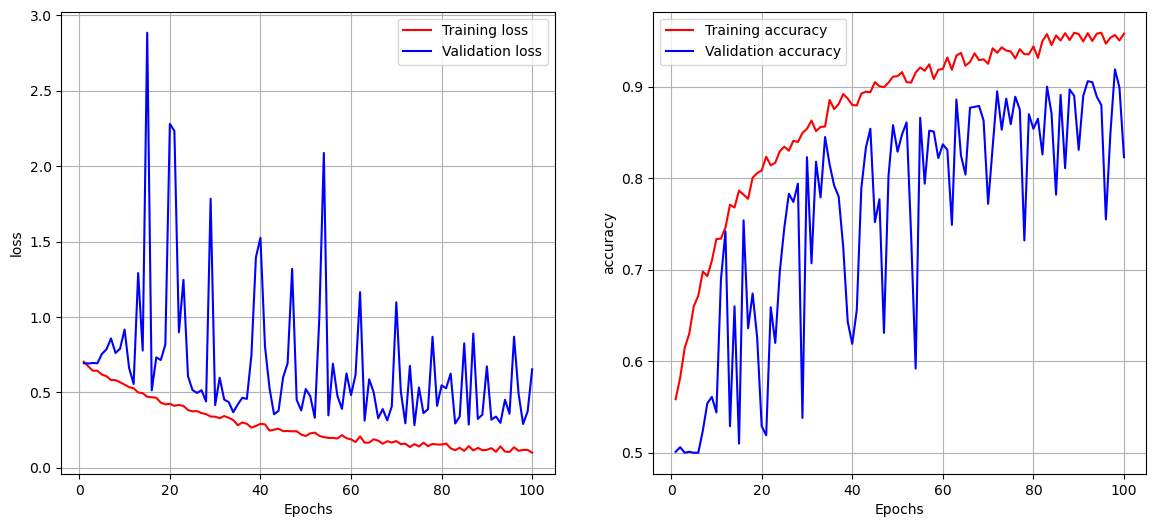

In [15]:
# plot training learning curves for loss and accuracy
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

In [16]:
# check best model seen by validation loss on test data
test_model = keras.models.load_model(
    "../models/ch09-xception-example.keras")

test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8926 - loss: 0.2966
Test accuracy: 0.888


You should usually find that the model can achieve around 90% test accuracy usually.  The last model we did before using
data augmentation usually achieves above 80%, maybe around 83% on average.  As you can see, the architecture
best practices has an immediate and sizable impact on the model performance.

At this point, if you want to further improve performance, you should start systematically
tuning the hyperparameters of your architecture.

Note that these architecture best practices are relevant to computer vision in general,
not just image classification. For example, Xception is used as the standard convolutional
base in DeepLabV3, a popular state-of-the-art image segmentation solution.